# Task 2 — Open-set evaluation

Repeat of Task 1 with the addition of ≥ 100 images of **unenrolled persons** (from `data/test/`).
Goal: check whether the presence of unknown identities increases the False Positive Rate (FPR / FAR).

### Protocol
| Probe type | Source | Expected decision | Label |
|---|---|---|---|
| Genuine | `enrolled_test/` — correct user | Accept | 1 |
| Enrolled impostor | `enrolled_test/` — wrong enrolled user | Reject | 0 |
| **Unknown** | `test/` — not in DB at all | Reject | 0 |

For unknowns the system's best-match score (`query_top1`) is used — if it exceeds the threshold, the system wrongly grants access.

## 1. Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding
from src.database import EmbeddingDB
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED              = 44
DEFAULT_THRESH    = 0.4
MIN_UNKNOWNS      = 100
ENROLLED_TEST_DIR = Path('../data/enrolled_test')
UNKNOWN_DIR       = Path('../data/test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
print(f'Enrolled users in DB : {len(enrolled_users)}')

Loading model...
Enrolled users in DB : 105


## 2. Enrolled probes — genuine + enrolled-impostor (same as Task 1)

In [2]:
print('Extracting embeddings from enrolled_test/ ...')

probes = []  # (user_id, embedding)
for user_dir in sorted(d for d in ENROLLED_TEST_DIR.iterdir()
                       if d.is_dir() and d.name in enrolled_users):
    for img_path in list_images(user_dir):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        emb = get_embedding(app, img, fallback=True)
        if emb is not None:
            probes.append((user_dir.name, emb))

print(f'Valid enrolled probes : {len(probes)}')

user_list = sorted(enrolled_users)
rng = random.Random(SEED)

scores_genuine      = []
scores_enrolled_imp = []
meta_enrolled       = []  # (true_user, matched_user, pair_type)

for user_id, probe_emb in probes:
    refs = db.get_user_embeddings(user_id)
    if refs:
        sim = max(float(np.dot(probe_emb, ref)) for ref in refs)
        scores_genuine.append(sim)
        meta_enrolled.append((user_id, user_id, 'genuine'))

    candidates = [u for u in user_list if u != user_id]
    for imp_id in rng.sample(candidates, min(10, len(candidates))):
        imp_refs = db.get_user_embeddings(imp_id)
        if imp_refs:
            sim = max(float(np.dot(probe_emb, ref)) for ref in imp_refs)
            scores_enrolled_imp.append(sim)
            meta_enrolled.append((user_id, imp_id, 'enrolled_impostor'))

print(f'Genuine pairs           : {len(scores_genuine)}')
print(f'Enrolled impostor pairs : {len(scores_enrolled_imp)}')

Extracting embeddings from enrolled_test/ ...
Valid enrolled probes : 2397
Genuine pairs           : 2397
Enrolled impostor pairs : 23970


## 3. Unknown probes — persons not in the DB

In [3]:
unknown_dirs = sorted(
    d for d in UNKNOWN_DIR.iterdir()
    if d.is_dir() and d.name not in enrolled_users
)
print(f'Unknown persons found : {len(unknown_dirs)}')

unknown_probes = []  # (person_id, embedding)
for person_dir in unknown_dirs:
    for img_path in list_images(person_dir):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        emb = get_embedding(app, img, fallback=True)
        if emb is not None:
            unknown_probes.append((person_dir.name, emb))

print(f'Valid unknown probes  : {len(unknown_probes)}')
if len(unknown_probes) < MIN_UNKNOWNS:
    print(f'WARNING: only {len(unknown_probes)} — need >= {MIN_UNKNOWNS}')

Unknown persons found : 43
Valid unknown probes  : 3549


In [4]:
# For each unknown probe: best match in DB via query_top1
# (db has no get_all() — use query_top1 which returns the nearest neighbour)
print('Scoring unknown probes against DB ...')

scores_unknown = []
meta_unknown   = []  # (unknown_person, best_matched_enrolled_user)

for person_id, probe_emb in unknown_probes:
    matched_user, sim = db.query_top1(probe_emb)
    scores_unknown.append(sim)
    meta_unknown.append((person_id, matched_user))

scores_unknown = np.array(scores_unknown)
print(f'Unknown probes scored : {len(scores_unknown)}')
print(f'  Mean score  : {scores_unknown.mean():.4f}')
print(f'  Max score   : {scores_unknown.max():.4f}')
print(f'  Would-be FA : {(scores_unknown >= DEFAULT_THRESH).sum()}  '
      f'({(scores_unknown >= DEFAULT_THRESH).mean()*100:.1f}%)')

Scoring unknown probes against DB ...
Unknown probes scored : 3549
  Mean score  : 0.1930
  Max score   : 0.3868
  Would-be FA : 0  (0.0%)


## 4. Score distributions — three groups

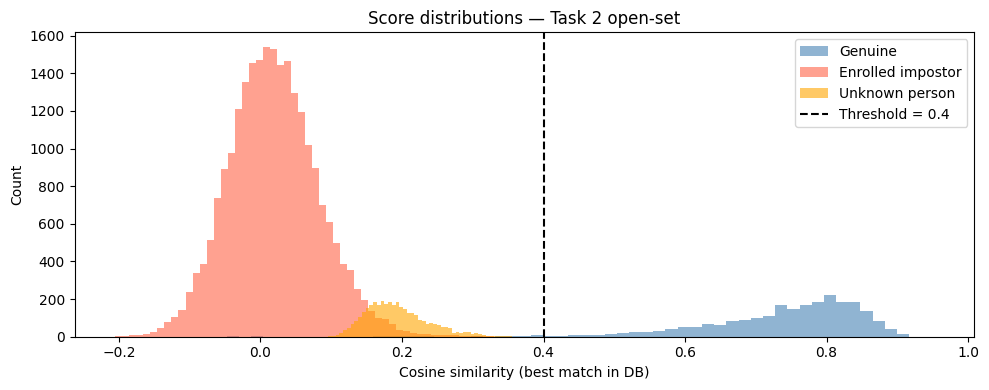

In [5]:
out_dir = Path('../results/task2')
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_genuine,      bins=60, alpha=0.60, color='steelblue', label='Genuine')
ax.hist(scores_enrolled_imp, bins=60, alpha=0.60, color='tomato',    label='Enrolled impostor')
ax.hist(scores_unknown,      bins=60, alpha=0.60, color='orange',    label='Unknown person')
ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.5, label=f'Threshold = {DEFAULT_THRESH}')
ax.set_xlabel('Cosine similarity (best match in DB)')
ax.set_ylabel('Count')
ax.set_title('Score distributions — Task 2 open-set')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'score_distributions.png', dpi=150)
plt.show()

## 5. Metrics comparison — baseline vs open-set

In [6]:
# Baseline: enrolled genuine + enrolled impostor (identical to Task 1)
scores_base = np.concatenate([scores_genuine, scores_enrolled_imp])
labels_base = np.concatenate([
    np.ones(len(scores_genuine)),
    np.zeros(len(scores_enrolled_imp))
])
far_b, frr_b, acc_b = compute_far_frr(scores_base, labels_base, DEFAULT_THRESH)

# Open-set: genuine + enrolled impostor + unknowns
scores_open = np.concatenate([scores_genuine, scores_enrolled_imp, scores_unknown])
labels_open = np.concatenate([
    np.ones(len(scores_genuine)),
    np.zeros(len(scores_enrolled_imp)),
    np.zeros(len(scores_unknown)),
])
far_o, frr_o, acc_o = compute_far_frr(scores_open, labels_open, DEFAULT_THRESH)

# Unknown-only FAR
far_unk, _, _ = compute_far_frr(scores_unknown, np.zeros(len(scores_unknown)), DEFAULT_THRESH)

print(f'{"":30s} {"Baseline":>12s} {"Open-set":>12s}')
print('-' * 56)
print(f'{"FAR (all impostors)":30s} {far_b*100:>11.2f}% {far_o*100:>11.2f}%')
print(f'{"FAR (unknowns only)":30s} {"—":>12s} {far_unk*100:>11.2f}%')
print(f'{"FRR":30s} {frr_b*100:>11.2f}% {frr_o*100:>11.2f}%')
print(f'{"Accuracy":30s} {acc_b*100:>11.2f}% {acc_o*100:>11.2f}%')
print()
print(f'Unknown probes that triggered FA : '
      f'{int((scores_unknown >= DEFAULT_THRESH).sum())} / {len(scores_unknown)}')

                                   Baseline     Open-set
--------------------------------------------------------
FAR (all impostors)                   0.00%        0.00%
FAR (unknowns only)                       —        0.00%
FRR                                   2.09%        2.09%
Accuracy                             99.81%       99.83%

Unknown probes that triggered FA : 0 / 3549


## 6. ROC curves — baseline vs open-set

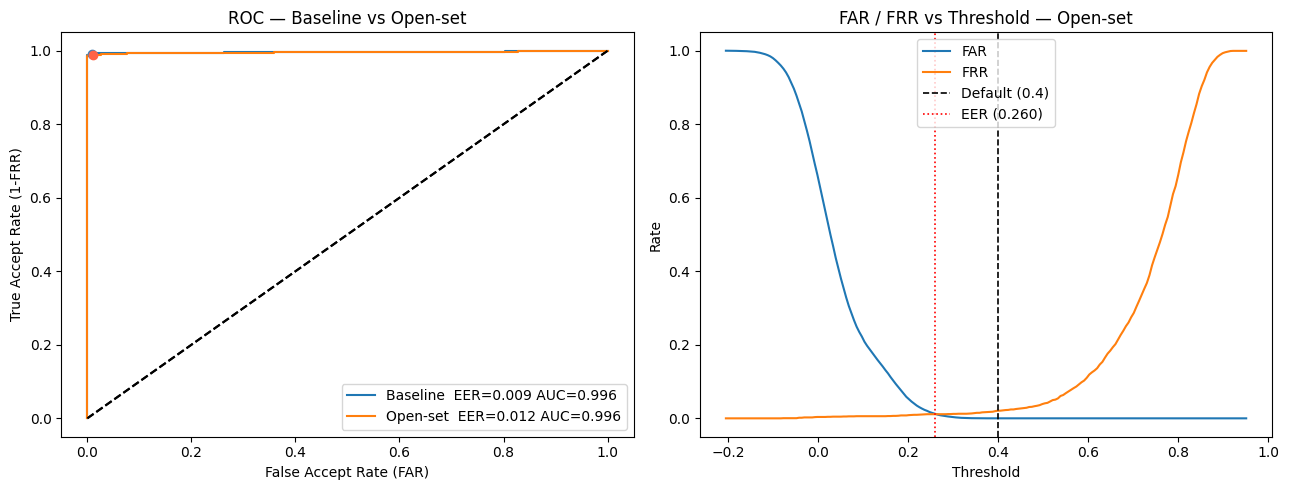

AUC baseline : 0.9963
AUC open-set : 0.9958


In [7]:
fpr_b, tpr_b, thr_b = compute_roc(scores_base, labels_base)
fpr_o, tpr_o, thr_o = compute_roc(scores_open, labels_open)

eer_b, eer_thr_b = eer(fpr_b, tpr_b, thr_b)
eer_o, eer_thr_o = eer(fpr_o, tpr_o, thr_o)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_roc(fpr_b, tpr_b, ax=axes[0], label=f'Baseline  EER={eer_b:.3f}')
plot_roc(fpr_o, tpr_o, ax=axes[0], label=f'Open-set  EER={eer_o:.3f}')
axes[0].scatter([eer_b], [1-eer_b], color='steelblue', zorder=5)
axes[0].scatter([eer_o], [1-eer_o], color='tomato',    zorder=5)
axes[0].set_title('ROC — Baseline vs Open-set')
axes[0].legend()

plot_far_frr_vs_threshold(scores_open, labels_open, ax=axes[1])
axes[1].axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2, label=f'Default ({DEFAULT_THRESH})')
axes[1].axvline(eer_thr_o,      color='r', ls=':',  lw=1.2, label=f'EER ({eer_thr_o:.3f})')
axes[1].set_title('FAR / FRR vs Threshold — Open-set')
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / 'roc_comparison.png', dpi=150)
plt.show()

print(f'AUC baseline : {auc(fpr_b, tpr_b):.4f}')
print(f'AUC open-set : {auc(fpr_o, tpr_o):.4f}')

## 7. Which enrolled users attract unknown impostors?

In [8]:
df_unk = pd.DataFrame(meta_unknown, columns=['unknown_person', 'best_match'])
df_unk['score']       = scores_unknown
df_unk['false_accept'] = scores_unknown >= DEFAULT_THRESH

fa_df = df_unk[df_unk['false_accept']].copy()

if len(fa_df) == 0:
    print('No unknown persons were falsely accepted at this threshold.')
else:
    print(f'Falsely accepted unknown probes: {len(fa_df)}')

    top_attracts = fa_df['best_match'].value_counts().reset_index()
    top_attracts.columns = ['enrolled_user', 'n_false_accepts']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_n = min(15, len(top_attracts))
    axes[0].barh(top_attracts['enrolled_user'].head(top_n),
                 top_attracts['n_false_accepts'].head(top_n), color='tomato')
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Number of false accepts')
    axes[0].set_title('Enrolled users attracting unknown impostors')

    axes[1].hist(fa_df['score'], bins=30, color='orange', edgecolor='k', alpha=0.8)
    axes[1].axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.5,
                    label=f'Threshold = {DEFAULT_THRESH}')
    axes[1].set_xlabel('Cosine similarity')
    axes[1].set_title('Scores of falsely accepted unknowns')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(out_dir / 'unknown_false_accepts.png', dpi=150)
    plt.show()

    print('\nTop enrolled users acting as decoys:')
    display(top_attracts)

    print('\nFalsely accepted unknowns:')
    display(fa_df[['unknown_person', 'best_match', 'score']]
              .sort_values('score', ascending=False)
              .reset_index(drop=True))

No unknown persons were falsely accepted at this threshold.


## 8. Summary

In [9]:
print('=' * 60)
print('TASK 2 — OPEN-SET RESULTS')
print('=' * 60)
print(f'  Enrolled users            : {len(enrolled_users)}')
print(f'  Genuine probes            : {len(scores_genuine)}')
print(f'  Enrolled impostor probes  : {len(scores_enrolled_imp)}')
print(f'  Unknown probes            : {len(scores_unknown)}  (from {len(unknown_dirs)} persons)')
print()
print(f'  Threshold                 : {DEFAULT_THRESH}')
print()
print(f'  --- Baseline (enrolled only) ---')
print(f'  FAR  : {far_b*100:.2f}%')
print(f'  FRR  : {frr_b*100:.2f}%')
print(f'  Acc  : {acc_b*100:.2f}%')
print(f'  EER  : {eer_b*100:.2f}%  (threshold {eer_thr_b:.4f})')
print()
print(f'  --- Open-set (enrolled + unknowns) ---')
print(f'  FAR  : {far_o*100:.2f}%  (delta: {(far_o-far_b)*100:+.2f} pp)')
print(f'  FRR  : {frr_o*100:.2f}%')
print(f'  Acc  : {acc_o*100:.2f}%')
print(f'  EER  : {eer_o*100:.2f}%  (threshold {eer_thr_o:.4f})')
print()
print(f'  Unknown FA rate : {far_unk*100:.2f}%  '
      f'({int((scores_unknown >= DEFAULT_THRESH).sum())} / {len(scores_unknown)} probes)')
print('=' * 60)

TASK 2 — OPEN-SET RESULTS
  Enrolled users            : 105
  Genuine probes            : 2397
  Enrolled impostor probes  : 23970
  Unknown probes            : 3549  (from 43 persons)

  Threshold                 : 0.4

  --- Baseline (enrolled only) ---
  FAR  : 0.00%
  FRR  : 2.09%
  Acc  : 99.81%
  EER  : 0.86%  (threshold 0.1842)

  --- Open-set (enrolled + unknowns) ---
  FAR  : 0.00%  (delta: +0.00 pp)
  FRR  : 2.09%
  Acc  : 99.83%
  EER  : 1.18%  (threshold 0.2597)

  Unknown FA rate : 0.00%  (0 / 3549 probes)
